In [1]:
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("ATEM environment loaded successfully!")

ATEM environment loaded successfully!


In [2]:
UNKNOWN_TEST_PATH = r"E:\Hybrid_IDS_Project\dataset\processed\unknown_test.csv"

unknown_df = pd.read_csv(UNKNOWN_TEST_PATH)

print("=" * 60)
print("UNKNOWN TEST DATA")
print("=" * 60)

print("Shape:", unknown_df.shape)
print("\nColumns:")
print(unknown_df.columns.tolist())

print("\nLabel Distribution:")
print(unknown_df["Label"].value_counts())

UNKNOWN TEST DATA
Shape: (25122, 79)

Columns:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG

In [3]:
X_unknown = unknown_df.drop("Label", axis=1)

y_unknown = unknown_df["Label"].apply(
    lambda x: 0 if x == "BENIGN" else 1
).values

print("=" * 60)
print("FEATURE / LABEL PREPARATION")
print("=" * 60)

print("X_unknown shape:", X_unknown.shape)
print("y_unknown shape:", y_unknown.shape)

print("\nBinary Label Distribution:")
print(pd.Series(y_unknown).value_counts())

FEATURE / LABEL PREPARATION
X_unknown shape: (25122, 78)
y_unknown shape: (25122,)

Binary Label Distribution:
1    12561
0    12561
Name: count, dtype: int64


In [4]:
# ============================================================
# Cell 4: Load Random Forest Model
# ============================================================

RF_MODEL_PATH = r"E:\Hybrid_IDS_Project\dataset\models\random_forest_unknown.pkl"

rf = joblib.load(RF_MODEL_PATH)

print("=" * 60)
print("Random Forest Model Loaded")
print("=" * 60)

print(type(rf))
print(rf)

Random Forest Model Loaded
<class 'sklearn.ensemble._forest.RandomForestClassifier'>
RandomForestClassifier(class_weight='balanced', max_depth=20, n_jobs=-1,
                       random_state=42)


In [5]:
# ============================================================
# Cell 5: Load OCSVM Model
# ============================================================

OCSVM_MODEL_PATH = r"E:\Hybrid_IDS_Project\dataset\models\ocsvm_unknown.pkl"

ocsvm = joblib.load(OCSVM_MODEL_PATH)

print("=" * 60)
print("OCSVM Model Loaded")
print("=" * 60)

print(type(ocsvm))
print(ocsvm)

OCSVM Model Loaded
<class 'sklearn.svm._classes.OneClassSVM'>
OneClassSVM(nu=0.05)


In [6]:
# ============================================================
# Cell 6: Random Forest Outputs
# ============================================================

rf_pred = rf.predict(X_unknown)

rf_proba = rf.predict_proba(X_unknown)

rf_confidence = np.max(rf_proba, axis=1)

print("=" * 60)
print("RANDOM FOREST OUTPUT")
print("=" * 60)

print("Prediction Shape :", rf_pred.shape)
print("Probability Shape:", rf_proba.shape)

print("\nPrediction Distribution:")
print(pd.Series(rf_pred).value_counts().sort_index())

print("\nFirst 5 Probability Vectors:")
print(rf_proba[:5])

print("\nFirst 10 Confidence Scores:")
print(rf_confidence[:10])

print("\nConfidence Statistics:")
print("Minimum :", rf_confidence.min())
print("Maximum :", rf_confidence.max())
print("Mean    :", rf_confidence.mean())
print("Median  :", np.median(rf_confidence))

RANDOM FOREST OUTPUT
Prediction Shape : (25122,)
Probability Shape: (25122, 2)

Prediction Distribution:
0    25102
1       20
Name: count, dtype: int64

First 5 Probability Vectors:
[[0.52 0.48]
 [0.82 0.18]
 [0.5  0.5 ]
 [0.72 0.28]
 [0.5  0.5 ]]

First 10 Confidence Scores:
[0.52 0.82 0.5  0.72 0.5  0.72 0.5  0.5  0.72 0.72]

Confidence Statistics:
Minimum : 0.5
Maximum : 0.94
Mean    : 0.7277688878274023
Median  : 0.71


e:\Hybrid_IDS_Project\dataset\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
e:\Hybrid_IDS_Project\dataset\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [7]:
# ============================================================
# Cell 7: Random Forest Prediction Entropy
# ============================================================

# Avoid log(0)
epsilon = 1e-10

rf_proba_safe = np.clip(rf_proba, epsilon, 1 - epsilon)

rf_entropy = -np.sum(
    rf_proba_safe * np.log2(rf_proba_safe),
    axis=1
)

print("=" * 60)
print("RF ENTROPY")
print("=" * 60)

print("Entropy Shape :", rf_entropy.shape)

print("\nFirst 10 Entropy Values:")
print(rf_entropy[:10])

print("\nEntropy Statistics:")
print("Minimum :", rf_entropy.min())
print("Maximum :", rf_entropy.max())
print("Mean    :", rf_entropy.mean())
print("Median  :", np.median(rf_entropy))

RF ENTROPY
Entropy Shape : (25122,)

First 10 Entropy Values:
[0.99884554 0.68007705 1.         0.85545081 1.         0.85545081
 1.         1.         0.85545081 0.85545081]

Entropy Statistics:
Minimum : 0.32744491915447627
Maximum : 1.0
Mean    : 0.7755051576835119
Median  : 0.8687212463394045


In [8]:
# ============================================================
# Cell 8: OCSVM Anomaly Score
# ============================================================

ocsvm_score = ocsvm.decision_function(X_unknown)

print("=" * 60)
print("OCSVM DECISION SCORE")
print("=" * 60)

print("Score Shape :", ocsvm_score.shape)

print("\nFirst 10 Scores:")
print(ocsvm_score[:10])

print("\nScore Statistics:")
print("Minimum :", ocsvm_score.min())
print("Maximum :", ocsvm_score.max())
print("Mean    :", ocsvm_score.mean())
print("Median  :", np.median(ocsvm_score))

e:\Hybrid_IDS_Project\dataset\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but OneClassSVM was fitted without feature names
  warnings.warn(


OCSVM DECISION SCORE
Score Shape : (25122,)

First 10 Scores:
[-71.58100552 -71.58100552 -71.58100552 -71.58100552 -71.58100552
 -71.58100552 -71.58100552 -71.58100552 -71.58100552 -71.58100552]

Score Statistics:
Minimum : -71.58100552373406
Maximum : -71.58100552373406
Mean    : -71.58100552373409
Median  : -71.58100552373406


In [9]:
import os

print("=" * 60)
print("MODEL / SCALER FILES")
print("=" * 60)

models_path = r"E:\Hybrid_IDS_Project\dataset\models"

for file in sorted(os.listdir(models_path)):
    print(file)

MODEL / SCALER FILES
best_mlp.keras
cnn.keras
cnn_unknown.keras
hybrid.pkl
lof.pkl
mlp_unknown.pkl
ocsvm.pkl
ocsvm_unknown.pkl
random_forest.pkl
random_forest_unknown.pkl
scaler.pkl


In [10]:
print("=" * 60)
print("MODEL INFORMATION")
print("=" * 60)

print("RF features:", rf.n_features_in_)
print("OCSVM features:", ocsvm.n_features_in_)

MODEL INFORMATION
RF features: 78
OCSVM features: 78


In [11]:
# ============================================================
# Cell 9: Load Existing Scaler
# ============================================================

SCALER_PATH = r"E:\Hybrid_IDS_Project\dataset\models\scaler.pkl"

scaler = joblib.load(SCALER_PATH)

print("=" * 60)
print("Scaler Loaded")
print("=" * 60)

print("Scaler type:", type(scaler))

print("\nNumber of features:", scaler.n_features_in_)

print("\nFirst 10 means:")
print(scaler.mean_[:10])

print("\nFirst 10 scale values:")
print(scaler.scale_[:10])

Scaler Loaded
Scaler type: <class 'sklearn.preprocessing._data.StandardScaler'>

Number of features: 78

First 10 means:
[8.71990352e+03 1.64173699e+07 1.03037899e+01 1.16224918e+01
 6.10158965e+02 1.82349241e+04 2.31514308e+02 1.92083109e+01
 6.34238399e+01 7.73979044e+01]

First 10 scale values:
[1.90428440e+04 3.50917616e+07 7.96406494e+02 1.05956480e+03
 1.06018172e+04 2.40417399e+06 7.55417274e+02 6.03911225e+01
 1.95081608e+02 2.97147766e+02]


In [12]:
# ============================================================
# Cell 10: Scale Unknown Test Data
# ============================================================

X_unknown_scaled = scaler.transform(X_unknown)

print("=" * 60)
print("UNKNOWN DATA SCALED")
print("=" * 60)

print("Original shape:", X_unknown.shape)
print("Scaled shape  :", X_unknown_scaled.shape)

print("\nFirst 5 scaled rows:")
print(X_unknown_scaled[:5])

UNKNOWN DATA SCALED
Original shape: (25122, 78)
Scaled shape  : (25122, 78)

First 5 scaled rows:
[[-3.36033586e-02  1.24773645e+00 -1.63709096e-03 -2.47506505e-03
  -2.71801484e-02 -7.47821255e-03  1.19782397e-01 -3.18065140e-01
  -1.41715369e-01  1.00742568e-01 -3.54279309e-01 -6.11027011e-01
  -4.95131764e-01 -3.31789636e-01 -5.32007748e-02 -2.33841533e-01
   4.62671914e-01  2.01673857e-01  1.08201144e-03 -5.57699309e-02
   1.00290750e+00  3.62748066e-01  1.61731470e-01  7.21430092e-03
  -1.23435022e-01  1.63649403e+00  6.19503049e-01  4.70788777e-01
   2.89715618e-01 -1.20000069e-01 -2.24712420e-01  0.00000000e+00
  -5.64764818e-03  0.00000000e+00  1.32541636e-03  1.85660862e-03
  -2.11874118e-01 -1.70929028e-01 -6.64524192e-01 -3.51026657e-01
  -5.04457197e-01 -3.61960577e-01 -3.10228652e-01 -1.82568507e-01
  -2.24712420e-01 -1.65400634e-02  1.54447590e+00 -6.73634378e-01
  -3.35740413e-01 -5.64764818e-03 -1.65762002e-02  4.27733037e-01
  -5.23078587e-01 -1.41715369e-01 -4.9513176

In [13]:
# ============================================================
# Cell 11: RF Prediction Using Correct Scaling
# ============================================================

rf_pred = rf.predict(X_unknown_scaled)
rf_proba = rf.predict_proba(X_unknown_scaled)

rf_confidence = np.max(rf_proba, axis=1)

print("=" * 60)
print("RF PREDICTION AFTER SCALING")
print("=" * 60)

print("Prediction Distribution:")
print(pd.Series(rf_pred).value_counts().sort_index())

print("\nConfidence Statistics:")
print("Minimum :", rf_confidence.min())
print("Maximum :", rf_confidence.max())
print("Mean    :", rf_confidence.mean())
print("Median  :", np.median(rf_confidence))

RF PREDICTION AFTER SCALING
Prediction Distribution:
0    24981
1      141
Name: count, dtype: int64

Confidence Statistics:
Minimum : 0.5
Maximum : 1.0
Mean    : 0.8904883042075257
Median  : 0.92


In [14]:
# ============================================================
# Cell 9: Recreate the Unknown-Attack Experiment Scaler
# ============================================================

TRAIN_KNOWN_PATH = r"E:\Hybrid_IDS_Project\dataset\processed\train_known.csv"

train_known_df = pd.read_csv(TRAIN_KNOWN_PATH)

# Separate features
X_train_known = train_known_df.drop("Label", axis=1)

print("=" * 60)
print("KNOWN TRAINING DATA")
print("=" * 60)

print("Shape:", X_train_known.shape)

KNOWN TRAINING DATA
Shape: (2006589, 78)


In [15]:
from sklearn.preprocessing import StandardScaler

unknown_scaler = StandardScaler()

unknown_scaler.fit(X_train_known)

print("=" * 60)
print("UNKNOWN-ATTACK SCALER")
print("=" * 60)

print("Number of features:", unknown_scaler.n_features_in_)

print("\nFirst 10 means:")
print(unknown_scaler.mean_[:10])

print("\nFirst 10 scale values:")
print(unknown_scaler.scale_[:10])

UNKNOWN-ATTACK SCALER
Number of features: 78

First 10 means:
[8.71365654e+03 1.64259722e+07 1.06012432e+01 1.20225746e+01
 6.04680168e+02 1.91414779e+04 2.31405006e+02 1.92207542e+01
 6.33648586e+01 7.73433201e+01]

First 10 scale values:
[1.90369838e+04 3.50950951e+07 8.25709008e+02 1.10057600e+03
 6.74702212e+03 2.49361617e+06 7.54070172e+02 6.04891676e+01
 1.94642006e+02 2.96624892e+02]


In [16]:
# ============================================================
# Cell 11: Transform Unknown Test Data
# ============================================================

X_unknown_scaled = unknown_scaler.transform(X_unknown)

print("=" * 60)
print("UNKNOWN TEST DATA SCALED")
print("=" * 60)

print("Original shape:", X_unknown.shape)
print("Scaled shape  :", X_unknown_scaled.shape)

UNKNOWN TEST DATA SCALED
Original shape: (25122, 78)
Scaled shape  : (25122, 78)


In [17]:
# ============================================================
# Cell 12: RF Reproduction Check
# ============================================================

rf_pred = rf.predict(X_unknown_scaled)
rf_proba = rf.predict_proba(X_unknown_scaled)

rf_confidence = np.max(rf_proba, axis=1)

print("=" * 60)
print("RF REPRODUCTION CHECK")
print("=" * 60)

print("\nPrediction Distribution:")
print(pd.Series(rf_pred).value_counts().sort_index())

print("\nConfidence Statistics:")
print("Minimum :", rf_confidence.min())
print("Maximum :", rf_confidence.max())
print("Mean    :", rf_confidence.mean())
print("Median  :", np.median(rf_confidence))

RF REPRODUCTION CHECK

Prediction Distribution:
0    23269
1     1853
Name: count, dtype: int64

Confidence Statistics:
Minimum : 0.5
Maximum : 1.0
Mean    : 0.923400450642847
Median  : 0.9999521399956877


In [18]:
# ============================================================
# Cell 13: OCSVM Decision Score
# ============================================================

ocsvm_score = ocsvm.decision_function(X_unknown_scaled)

print("=" * 60)
print("OCSVM DECISION SCORE")
print("=" * 60)

print("Score Shape :", ocsvm_score.shape)

print("\nFirst 10 Scores:")
print(ocsvm_score[:10])

print("\nScore Statistics:")
print("Minimum :", ocsvm_score.min())
print("Maximum :", ocsvm_score.max())
print("Mean    :", ocsvm_score.mean())
print("Median  :", np.median(ocsvm_score))

print("\nUnique Score Values:")
print(len(np.unique(ocsvm_score)))

OCSVM DECISION SCORE
Score Shape : (25122,)

First 10 Scores:
[44.98048102 26.92652605 33.71528919 28.11215684 33.70802812 29.32018973
 33.33741122 21.81954596 28.98379527 29.49221414]

Score Statistics:
Minimum : -71.58100552373406
Maximum : 59.48676245449715
Mean    : 4.28546130945593
Median  : 25.799065630470082

Unique Score Values:
25122


In [19]:
# ============================================================
# Cell 14: Create ATEM Dataset
# ============================================================

# RF entropy
epsilon = 1e-10
rf_proba_safe = np.clip(rf_proba, epsilon, 1 - epsilon)

rf_entropy = -np.sum(
    rf_proba_safe * np.log2(rf_proba_safe),
    axis=1
)

# RF correctness
rf_correct = (rf_pred == y_unknown).astype(int)

# Create ATEM dataframe
atem_df = pd.DataFrame({
    "RF_Prediction": rf_pred,
    "RF_Confidence": rf_confidence,
    "RF_Entropy": rf_entropy,
    "OCSVM_Score": ocsvm_score,
    "Actual": y_unknown,
    "RF_Correct": rf_correct
})

print("=" * 60)
print("ATEM DATASET CREATED")
print("=" * 60)

print("Shape:", atem_df.shape)

print("\nColumns:")
print(atem_df.columns.tolist())

print("\nFirst 10 rows:")
print(atem_df.head(10))

print("\nRF Correctness:")
print(atem_df["RF_Correct"].value_counts())

print("\nRF Accuracy:")
print(atem_df["RF_Correct"].mean())

ATEM DATASET CREATED
Shape: (25122, 6)

Columns:
['RF_Prediction', 'RF_Confidence', 'RF_Entropy', 'OCSVM_Score', 'Actual', 'RF_Correct']

First 10 rows:
   RF_Prediction  RF_Confidence    RF_Entropy  OCSVM_Score  Actual  RF_Correct
0              0       1.000000  3.466198e-09    44.980481       1           0
1              0       1.000000  3.466198e-09    26.926526       1           0
2              0       0.999996  7.565867e-05    33.715289       1           0
3              0       0.999907  1.373170e-03    28.112157       1           0
4              0       0.999996  7.565867e-05    33.708028       1           0
5              0       0.999933  1.020714e-03    29.320190       1           0
6              0       0.999988  2.073841e-04    33.337411       1           0
7              0       0.999992  1.526063e-04    21.819546       1           0
8              0       0.999923  1.167168e-03    28.983795       1           0
9              0       0.999943  8.890563e-04    29.49221

In [20]:
# ============================================================
# Cell 16: ATEM Feature Analysis
# ============================================================

feature_columns = [
    "RF_Prediction",
    "RF_Confidence",
    "RF_Entropy",
    "OCSVM_Score"
]

print("=" * 70)
print("ATEM FEATURE ANALYSIS")
print("=" * 70)

summary = atem_df.groupby("RF_Correct")[feature_columns].agg(
    ["mean", "median", "std", "min", "max"]
)

print(summary)

ATEM FEATURE ANALYSIS
           RF_Prediction                          RF_Confidence            \
                    mean median       std min max          mean    median   
RF_Correct                                                                  
0               0.000653    0.0  0.025544   0   1      0.881283  0.959877   
1               0.128194    0.0  0.334318   0   1      0.954761  1.000000   

                                    RF_Entropy                      \
                 std       min  max       mean    median       std   
RF_Correct                                                           
0           0.142205  0.500000  1.0   0.388157  0.242858  0.354492   
1           0.121467  0.500379  1.0   0.118831  0.000005  0.305587   

                              OCSVM_Score                                   \
                     min  max        mean     median        std        min   
RF_Correct                                                                   
0      

In [21]:
# ============================================================
# Cell 17: Correct vs Incorrect RF Samples
# ============================================================

print("=" * 70)
print("CORRECT vs INCORRECT RF PREDICTIONS")
print("=" * 70)

for feature in feature_columns:
    print(f"\n{feature}")
    print("-" * 40)

    print(
        atem_df.groupby("RF_Correct")[feature]
        .mean()
    )

CORRECT vs INCORRECT RF PREDICTIONS

RF_Prediction
----------------------------------------
RF_Correct
0    0.000653
1    0.128194
Name: RF_Prediction, dtype: float64

RF_Confidence
----------------------------------------
RF_Correct
0    0.881283
1    0.954761
Name: RF_Confidence, dtype: float64

RF_Entropy
----------------------------------------
RF_Correct
0    0.388157
1    0.118831
Name: RF_Entropy, dtype: float64

OCSVM_Score
----------------------------------------
RF_Correct
0   -12.573500
1    16.838363
Name: OCSVM_Score, dtype: float64


In [22]:
# ============================================================
# Cell 18: ATEM Train/Test Split
# ============================================================

from sklearn.model_selection import train_test_split

atem_features = [
    "RF_Prediction",
    "RF_Confidence",
    "RF_Entropy",
    "OCSVM_Score"
]

X_atem = atem_df[atem_features]
y_atem = atem_df["RF_Correct"]

X_atem_train, X_atem_test, y_atem_train, y_atem_test = train_test_split(
    X_atem,
    y_atem,
    test_size=0.30,
    random_state=42,
    stratify=y_atem
)

print("=" * 60)
print("ATEM TRAIN / TEST SPLIT")
print("=" * 60)

print("Training samples:", X_atem_train.shape)
print("Testing samples :", X_atem_test.shape)

print("\nTraining target distribution:")
print(y_atem_train.value_counts())

print("\nTesting target distribution:")
print(y_atem_test.value_counts())

ATEM TRAIN / TEST SPLIT
Training samples: (17585, 4)
Testing samples : (7537, 4)

Training target distribution:
RF_Correct
1    10080
0     7505
Name: count, dtype: int64

Testing target distribution:
RF_Correct
1    4320
0    3217
Name: count, dtype: int64


In [23]:
# ============================================================
# Cell 19: Train ATEM
# ============================================================

atem_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

atem_model.fit(X_atem_train, y_atem_train)

print("=" * 60)
print("ATEM TRAINING COMPLETED")
print("=" * 60)

print(atem_model)

ATEM TRAINING COMPLETED
LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)


In [24]:
# ============================================================
# Cell 20: ATEM Evaluation
# ============================================================

atem_pred = atem_model.predict(X_atem_test)

accuracy = accuracy_score(y_atem_test, atem_pred)
precision = precision_score(y_atem_test, atem_pred, zero_division=0)
recall = recall_score(y_atem_test, atem_pred, zero_division=0)
f1 = f1_score(y_atem_test, atem_pred, zero_division=0)

print("=" * 60)
print("ATEM PERFORMANCE")
print("=" * 60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_atem_test, atem_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_atem_test,
        atem_pred,
        target_names=["RF Incorrect", "RF Correct"],
        zero_division=0
    )
)

ATEM PERFORMANCE
Accuracy  : 0.9020
Precision : 0.8703
Recall    : 0.9741
F1 Score  : 0.9193

Confusion Matrix:
[[2590  627]
 [ 112 4208]]

Classification Report:
              precision    recall  f1-score   support

RF Incorrect       0.96      0.81      0.88      3217
  RF Correct       0.87      0.97      0.92      4320

    accuracy                           0.90      7537
   macro avg       0.91      0.89      0.90      7537
weighted avg       0.91      0.90      0.90      7537



In [26]:
# ============================================================
# Cell 21: ATEM Feature Importance
# ============================================================

importance = pd.DataFrame({
    "Feature": atem_features,
    "Coefficient": atem_model.coef_[0],
    "Absolute_Coefficient": np.abs(atem_model.coef_[0])
}).sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print("=" * 60)
print("ATEM FEATURE IMPORTANCE")
print("=" * 60)

print(importance)

ATEM FEATURE IMPORTANCE
         Feature  Coefficient  Absolute_Coefficient
0  RF_Prediction    18.528382             18.528382
2     RF_Entropy   -17.069343             17.069343
1  RF_Confidence    -4.768820              4.768820
3    OCSVM_Score     0.017985              0.017985


In [25]:
# ============================================================
# Cell 22: ATEM Trust Decision
# ============================================================

atem_trust = atem_model.predict(
    atem_df[atem_features]
)

print("=" * 60)
print("ATEM TRUST DECISIONS")
print("=" * 60)

print(pd.Series(atem_trust).value_counts().sort_index())

print("\nMeaning:")
print("1 = Trust Random Forest")
print("0 = Do NOT trust Random Forest")

ATEM TRUST DECISIONS
0     9028
1    16094
Name: count, dtype: int64

Meaning:
1 = Trust Random Forest
0 = Do NOT trust Random Forest


In [27]:
# ============================================================
# Cell 23: OCSVM Binary Decision
# ============================================================

ocsvm_pred = (ocsvm_score < 0).astype(int)

print("=" * 60)
print("OCSVM BINARY DECISION")
print("=" * 60)

print(pd.Series(ocsvm_pred).value_counts().sort_index())

print("\nMeaning:")
print("0 = Benign")
print("1 = Attack")

OCSVM BINARY DECISION
0    16420
1     8702
Name: count, dtype: int64

Meaning:
0 = Benign
1 = Attack


In [28]:
# ============================================================
# Cell 24: Hybrid Routing
# ============================================================

hybrid_pred = np.where(
    atem_trust == 1,
    rf_pred,
    ocsvm_pred
)

print("=" * 60)
print("HYBRID ROUTING COMPLETED")
print("=" * 60)

print("Hybrid Prediction Distribution:")
print(
    pd.Series(hybrid_pred)
    .value_counts()
    .sort_index()
)

HYBRID ROUTING COMPLETED
Hybrid Prediction Distribution:
0    16893
1     8229
Name: count, dtype: int64


In [29]:
# ============================================================
# Cell 25: Hybrid Evaluation
# ============================================================

hybrid_accuracy = accuracy_score(
    y_unknown,
    hybrid_pred
)

hybrid_precision = precision_score(
    y_unknown,
    hybrid_pred,
    zero_division=0
)

hybrid_recall = recall_score(
    y_unknown,
    hybrid_pred,
    zero_division=0
)

hybrid_f1 = f1_score(
    y_unknown,
    hybrid_pred,
    zero_division=0
)

print("=" * 60)
print("HYBRID IDS PERFORMANCE")
print("=" * 60)

print(f"Accuracy  : {hybrid_accuracy:.4f}")
print(f"Precision : {hybrid_precision:.4f}")
print(f"Recall    : {hybrid_recall:.4f}")
print(f"F1 Score  : {hybrid_f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_unknown, hybrid_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_unknown,
        hybrid_pred,
        target_names=["BENIGN", "ATTACK"],
        zero_division=0
    )
)

HYBRID IDS PERFORMANCE
Accuracy  : 0.8136
Precision : 0.9787
Recall    : 0.6412
F1 Score  : 0.7748

Confusion Matrix:
[[12386   175]
 [ 4507  8054]]

Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.73      0.99      0.84     12561
      ATTACK       0.98      0.64      0.77     12561

    accuracy                           0.81     25122
   macro avg       0.86      0.81      0.81     25122
weighted avg       0.86      0.81      0.81     25122



In [30]:
# ============================================================
# Cell 26: Proper Held-Out Hybrid Evaluation
# ============================================================

# Indices of samples never used to train ATEM
test_indices = X_atem_test.index

# RF predictions for held-out samples
rf_test_pred = atem_df.loc[test_indices, "RF_Prediction"].values

# OCSVM predictions for held-out samples
ocsvm_test_score = atem_df.loc[test_indices, "OCSVM_Score"].values
ocsvm_test_pred = (ocsvm_test_score < 0).astype(int)

# ATEM prediction: 1 = RF is trustworthy, 0 = RF is not trustworthy
atem_test_pred = atem_model.predict(X_atem_test)

# Actual network labels
y_test_final = atem_df.loc[test_indices, "Actual"].values

# Hybrid routing
hybrid_test_pred = np.where(
    atem_test_pred == 1,
    rf_test_pred,
    ocsvm_test_pred
)

print("=" * 60)
print("PROPER HELD-OUT HYBRID EVALUATION")
print("=" * 60)

print("Test samples:", len(y_test_final))

print("\nHybrid Confusion Matrix:")
print(confusion_matrix(y_test_final, hybrid_test_pred))

print("\nPerformance:")
print(
    classification_report(
        y_test_final,
        hybrid_test_pred,
        target_names=["BENIGN", "ATTACK"],
        zero_division=0
    )
)

PROPER HELD-OUT HYBRID EVALUATION
Test samples: 7537

Hybrid Confusion Matrix:
[[3707   42]
 [1354 2434]]

Performance:
              precision    recall  f1-score   support

      BENIGN       0.73      0.99      0.84      3749
      ATTACK       0.98      0.64      0.78      3788

    accuracy                           0.81      7537
   macro avg       0.86      0.82      0.81      7537
weighted avg       0.86      0.81      0.81      7537



In [31]:
# ============================================================
# Cell 27: RF vs Hybrid Comparison
# ============================================================

rf_test_accuracy = accuracy_score(
    y_test_final,
    rf_test_pred
)

hybrid_test_accuracy = accuracy_score(
    y_test_final,
    hybrid_test_pred
)

rf_test_recall = recall_score(
    y_test_final,
    rf_test_pred,
    zero_division=0
)

hybrid_test_recall = recall_score(
    y_test_final,
    hybrid_test_pred,
    zero_division=0
)

rf_test_f1 = f1_score(
    y_test_final,
    rf_test_pred,
    zero_division=0
)

hybrid_test_f1 = f1_score(
    y_test_final,
    hybrid_test_pred,
    zero_division=0
)

print("=" * 60)
print("RF vs HYBRID — SAME HELD-OUT TEST SET")
print("=" * 60)

comparison = pd.DataFrame({
    "Model": ["Random Forest", "RF + ATEM + OCSVM"],
    "Accuracy": [rf_test_accuracy, hybrid_test_accuracy],
    "Recall": [rf_test_recall, hybrid_test_recall],
    "F1": [rf_test_f1, hybrid_test_f1]
})

print(comparison)

RF vs HYBRID — SAME HELD-OUT TEST SET
               Model  Accuracy    Recall        F1
0      Random Forest  0.573172  0.151003  0.262325
1  RF + ATEM + OCSVM  0.814780  0.642555  0.777139


In [32]:
# ============================================================
# Cell 28: False-Negative Recovery
# ============================================================

rf_cm = confusion_matrix(y_test_final, rf_test_pred)
hybrid_cm = confusion_matrix(y_test_final, hybrid_test_pred)

rf_fn = rf_cm[1, 0]
hybrid_fn = hybrid_cm[1, 0]

recovered_fn = rf_fn - hybrid_fn

if rf_fn > 0:
    recovery_rate = (recovered_fn / rf_fn) * 100
else:
    recovery_rate = 0

print("=" * 60)
print("FALSE-NEGATIVE RECOVERY")
print("=" * 60)

print("RF False Negatives       :", rf_fn)
print("Hybrid False Negatives   :", hybrid_fn)
print("Recovered False Negatives:", recovered_fn)
print("Recovery Rate             :", f"{recovery_rate:.2f}%")

FALSE-NEGATIVE RECOVERY
RF False Negatives       : 3216
Hybrid False Negatives   : 1354
Recovered False Negatives: 1862
Recovery Rate             : 57.90%


In [33]:
# ============================================================
# Cell 29: ATEM Threshold Optimization
# ============================================================

atem_prob = atem_model.predict_proba(X_atem_test)[:, 1]

threshold_results = []

for threshold in np.arange(0.30, 0.91, 0.05):

    # 1 = Trust RF, 0 = Reject RF
    atem_decision = (atem_prob >= threshold).astype(int)

    hybrid_pred_threshold = np.where(
        atem_decision == 1,
        rf_test_pred,
        ocsvm_test_pred
    )

    cm = confusion_matrix(
        y_test_final,
        hybrid_pred_threshold
    )

    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(
        y_test_final,
        hybrid_pred_threshold
    )

    precision = precision_score(
        y_test_final,
        hybrid_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test_final,
        hybrid_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test_final,
        hybrid_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn
    })

threshold_df = pd.DataFrame(threshold_results)

print("=" * 70)
print("ATEM THRESHOLD OPTIMIZATION")
print("=" * 70)

print(threshold_df.to_string(index=False))

ATEM THRESHOLD OPTIMIZATION
 Threshold  Accuracy  Precision   Recall       F1  FP   FN   TP   TN
      0.30  0.801380   0.996963 0.606653 0.754308   7 1490 2298 3742
      0.35  0.800982   0.995238 0.606917 0.754018  11 1489 2299 3738
      0.40  0.800982   0.991831 0.609029 0.754661  19 1481 2307 3730
      0.45  0.799920   0.988432 0.609029 0.753675  27 1481 2307 3722
      0.50  0.814780   0.983037 0.642555 0.777139  42 1354 2434 3707
      0.55  0.811994   0.974770 0.642555 0.774543  63 1354 2434 3686
      0.60  0.807085   0.960537 0.642555 0.770009 100 1354 2434 3649
      0.65  0.800716   0.938940 0.645459 0.765019 159 1343 2445 3590
      0.70  0.797001   0.928626 0.645723 0.761756 188 1342 2446 3561
      0.75  0.797001   0.928626 0.645723 0.761756 188 1342 2446 3561
      0.80  0.797001   0.928626 0.645723 0.761756 188 1342 2446 3561
      0.85  0.797001   0.928626 0.645723 0.761756 188 1342 2446 3561
      0.90  0.797001   0.928626 0.645723 0.761756 188 1342 2446 3561


In [34]:
# ============================================================
# Cell 30: ATEM Routing Analysis
# ============================================================

FINAL_ATEM_THRESHOLD = 0.50

atem_prob = atem_model.predict_proba(X_atem_test)[:, 1]

atem_route = (atem_prob >= FINAL_ATEM_THRESHOLD).astype(int)

rf_route_count = np.sum(atem_route == 1)
ocsvm_route_count = np.sum(atem_route == 0)

total = len(atem_route)

print("=" * 60)
print("ATEM ROUTING ANALYSIS")
print("=" * 60)

print("Total samples :", total)

print("\nTrust RF:")
print("Samples   :", rf_route_count)
print("Percentage:", f"{rf_route_count / total * 100:.2f}%")

print("\nRoute to OCSVM:")
print("Samples   :", ocsvm_route_count)
print("Percentage:", f"{ocsvm_route_count / total * 100:.2f}%")

ATEM ROUTING ANALYSIS
Total samples : 7537

Trust RF:
Samples   : 4835
Percentage: 64.15%

Route to OCSVM:
Samples   : 2702
Percentage: 35.85%


In [35]:
# ============================================================
# Cell 31: Routing Correctness Analysis
# ============================================================

routing_analysis = pd.DataFrame({
    "Actual_RF_Correct": y_atem_test.values,
    "ATEM_Route": atem_route
})

routing_analysis["RF_Trusted"] = (
    routing_analysis["ATEM_Route"] == 1
)

print("=" * 60)
print("ATEM ROUTING vs RF CORRECTNESS")
print("=" * 60)

print(
    pd.crosstab(
        routing_analysis["Actual_RF_Correct"],
        routing_analysis["RF_Trusted"],
        rownames=["RF Actually Correct"],
        colnames=["ATEM Trusted RF"]
    )
)

ATEM ROUTING vs RF CORRECTNESS
ATEM Trusted RF      False  True 
RF Actually Correct              
0                     2590    627
1                      112   4208


In [36]:
# ============================================================
# Cell 32: ATEM + OCSVM Recovery Analysis
# ============================================================

test_idx = X_atem_test.index

rf_test = atem_df.loc[test_idx, "RF_Prediction"].values
actual_test = atem_df.loc[test_idx, "Actual"].values
ocsvm_test = (atem_df.loc[test_idx, "OCSVM_Score"].values < 0).astype(int)

atem_test = atem_route

# Samples where ATEM correctly identified an RF error
correctly_rejected = (
    (atem_test == 0) &
    (rf_test != actual_test)
)

# Among those, check whether OCSVM corrected the RF error
recovered_by_ocsvm = (
    correctly_rejected &
    (ocsvm_test == actual_test)
)

rejected_total = correctly_rejected.sum()
recovered_total = recovered_by_ocsvm.sum()

print("=" * 60)
print("ATEM + OCSVM RECOVERY ANALYSIS")
print("=" * 60)

print("RF errors correctly rejected by ATEM :", rejected_total)
print("Recovered by OCSVM                   :", recovered_total)

if rejected_total > 0:
    print(
        "OCSVM recovery among rejected RF errors:",
        f"{recovered_total / rejected_total * 100:.2f}%"
    )

ATEM + OCSVM RECOVERY ANALYSIS
RF errors correctly rejected by ATEM : 2590
Recovered by OCSVM                   : 1862
OCSVM recovery among rejected RF errors: 71.89%


In [37]:
# ============================================================
# Cell 33: Complete Error Transition Analysis
# ============================================================

# Final hybrid prediction
hybrid_test_pred = np.where(
    atem_test == 1,
    rf_test,
    ocsvm_test
)

rf_wrong = rf_test != actual_test
hybrid_wrong = hybrid_test_pred != actual_test

print("=" * 60)
print("ERROR TRANSITION ANALYSIS")
print("=" * 60)

print("RF errors       :", rf_wrong.sum())
print("Hybrid errors   :", hybrid_wrong.sum())
print("Recovered errors:", rf_wrong.sum() - hybrid_wrong.sum())

print(
    "Overall recovery:",
    f"{(rf_wrong.sum() - hybrid_wrong.sum()) / rf_wrong.sum() * 100:.2f}%"
)

ERROR TRANSITION ANALYSIS
RF errors       : 3217
Hybrid errors   : 1396
Recovered errors: 1821
Overall recovery: 56.61%


In [38]:
# ============================================================
# Cell 34: OCSVM Threshold Analysis
# ============================================================

ocsvm_scores_test = atem_df.loc[
    X_atem_test.index,
    "OCSVM_Score"
].values

thresholds = np.percentile(
    ocsvm_scores_test,
    [10, 20, 30, 40, 50, 60, 70, 80, 90]
)

ocsvm_threshold_results = []

for threshold in thresholds:

    ocsvm_pred_threshold = (
        ocsvm_scores_test < threshold
    ).astype(int)

    # ATEM keeps its selected routing
    hybrid_pred_threshold = np.where(
        atem_test == 1,
        rf_test,
        ocsvm_pred_threshold
    )

    cm = confusion_matrix(
        actual_test,
        hybrid_pred_threshold
    )

    tn, fp, fn, tp = cm.ravel()

    acc = accuracy_score(
        actual_test,
        hybrid_pred_threshold
    )

    precision = precision_score(
        actual_test,
        hybrid_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        actual_test,
        hybrid_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        actual_test,
        hybrid_pred_threshold,
        zero_division=0
    )

    ocsvm_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn
    })

ocsvm_threshold_df = pd.DataFrame(
    ocsvm_threshold_results
)

print("=" * 70)
print("OCSVM THRESHOLD ANALYSIS")
print("=" * 70)

print(
    ocsvm_threshold_df.to_string(index=False)
)

OCSVM THRESHOLD ANALYSIS
 Threshold  Accuracy  Precision   Recall       F1  FP   FN   TP   TN
-61.224759  0.595595   0.983029 0.198786 0.330698  13 3035  753 3736
-37.561668  0.689266   0.975658 0.391499 0.558779  37 2305 1483 3712
-37.473070  0.788112   0.983664 0.588173 0.736164  37 1560 2228 3712
 11.387776  0.820088   0.981775 0.654171 0.785171  46 1310 2478 3703
 25.463321  0.832294   0.977668 0.681890 0.803421  59 1205 2583 3690
 30.465846  0.861085   0.976364 0.741552 0.842911  68  979 2809 3681
 33.665124  0.900491   0.966523 0.830781 0.893526 109  641 3147 3640
 37.322203  0.901022   0.965707 0.832629 0.894244 112  634 3154 3637
 40.724319  0.901818   0.965486 0.834477 0.895214 113  627 3161 3636


In [39]:
# ============================================================
# Cell 35: Select OCSVM Threshold Using ATEM Training Data
# ============================================================

train_indices = X_atem_train.index

ocsvm_train_scores = atem_df.loc[
    train_indices,
    "OCSVM_Score"
].values

rf_train_pred = atem_df.loc[
    train_indices,
    "RF_Prediction"
].values

actual_train = atem_df.loc[
    train_indices,
    "Actual"
].values

# ATEM predictions on training portion
atem_train_prob = atem_model.predict_proba(
    X_atem_train
)[:, 1]

atem_train_route = (
    atem_train_prob >= 0.50
).astype(int)

thresholds_train = np.percentile(
    ocsvm_train_scores,
    [10, 20, 30, 40, 50, 60, 70, 80, 90]
)

train_threshold_results = []

for threshold in thresholds_train:

    ocsvm_train_pred = (
        ocsvm_train_scores < threshold
    ).astype(int)

    hybrid_train_pred = np.where(
        atem_train_route == 1,
        rf_train_pred,
        ocsvm_train_pred
    )

    f1 = f1_score(
        actual_train,
        hybrid_train_pred,
        zero_division=0
    )

    recall = recall_score(
        actual_train,
        hybrid_train_pred,
        zero_division=0
    )

    precision = precision_score(
        actual_train,
        hybrid_train_pred,
        zero_division=0
    )

    acc = accuracy_score(
        actual_train,
        hybrid_train_pred
    )

    cm = confusion_matrix(
        actual_train,
        hybrid_train_pred
    )

    tn, fp, fn, tp = cm.ravel()

    train_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn
    })

train_threshold_df = pd.DataFrame(
    train_threshold_results
)

print("=" * 70)
print("TRAINING-BASED OCSVM THRESHOLD SELECTION")
print("=" * 70)

print(
    train_threshold_df.to_string(index=False)
)

best_row = train_threshold_df.loc[
    train_threshold_df["F1"].idxmax()
]

BEST_OCSVM_THRESHOLD = best_row["Threshold"]

print("\nSelected threshold:")
print(BEST_OCSVM_THRESHOLD)

TRAINING-BASED OCSVM THRESHOLD SELECTION
 Threshold  Accuracy  Precision   Recall       F1  FP   FN   TP   TN
-60.223208  0.598806   0.978285 0.200274 0.332482  39 7016 1757 8773
-37.562084  0.689451   0.965954 0.391314 0.556989 121 5340 3433 8691
-37.473334  0.787831   0.976560 0.588852 0.734694 124 3607 5166 8688
 12.662775  0.817856   0.974932 0.651658 0.781171 147 3056 5717 8665
 25.913808  0.827580   0.970651 0.674798 0.796127 179 2853 5920 8633
 30.465918  0.861018   0.969441 0.744899 0.842465 206 2238 6535 8606
 33.674436  0.896218   0.960498 0.825943 0.888153 298 1527 7246 8514
 37.578086  0.897583   0.959894 0.829363 0.889867 304 1497 7276 8508
 40.781003  0.898777   0.959884 0.831871 0.891304 305 1475 7298 8507

Selected threshold:
40.78100327375024


In [40]:
# ============================================================
# Cell 36: Final Held-Out Hybrid Evaluation
# ============================================================

ocsvm_test_pred_final = (
    ocsvm_scores_test < BEST_OCSVM_THRESHOLD
).astype(int)

hybrid_final_pred = np.where(
    atem_test == 1,
    rf_test,
    ocsvm_test_pred_final
)

cm_final = confusion_matrix(
    actual_test,
    hybrid_final_pred
)

tn, fp, fn, tp = cm_final.ravel()

accuracy_final = accuracy_score(
    actual_test,
    hybrid_final_pred
)

precision_final = precision_score(
    actual_test,
    hybrid_final_pred,
    zero_division=0
)

recall_final = recall_score(
    actual_test,
    hybrid_final_pred,
    zero_division=0
)

f1_final = f1_score(
    actual_test,
    hybrid_final_pred,
    zero_division=0
)

print("=" * 70)
print("FINAL HELD-OUT HYBRID IDS")
print("=" * 70)

print("OCSVM Threshold :", BEST_OCSVM_THRESHOLD)

print("\nConfusion Matrix:")
print(cm_final)

print("\nPerformance:")
print(f"Accuracy  : {accuracy_final:.4f}")
print(f"Precision : {precision_final:.4f}")
print(f"Recall    : {recall_final:.4f}")
print(f"F1 Score  : {f1_final:.4f}")

print("\nFP :", fp)
print("FN :", fn)
print("TP :", tp)
print("TN :", tn)

FINAL HELD-OUT HYBRID IDS
OCSVM Threshold : 40.78100327375024

Confusion Matrix:
[[3636  113]
 [ 627 3161]]

Performance:
Accuracy  : 0.9018
Precision : 0.9655
Recall    : 0.8345
F1 Score  : 0.8952

FP : 113
FN : 627
TP : 3161
TN : 3636


In [41]:
# ============================================================
# Cell 37: Final Model Comparison
# ============================================================

# ------------------------------------------------------------
# 1. Random Forest only
# ------------------------------------------------------------

rf_only_pred = rf_test


# ------------------------------------------------------------
# 2. RF + OCSVM
# ------------------------------------------------------------

# OCSVM is applied directly to every sample
ocsvm_only_pred = (
    ocsvm_scores_test < BEST_OCSVM_THRESHOLD
).astype(int)

rf_ocsvm_pred = ocsvm_only_pred


# ------------------------------------------------------------
# 3. RF + ATEM + OCSVM
# ------------------------------------------------------------

hybrid_pred = np.where(
    atem_test == 1,
    rf_test,
    ocsvm_only_pred
)


# ------------------------------------------------------------
# Evaluation function
# ------------------------------------------------------------

def evaluate_model(name, y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }


# ------------------------------------------------------------
# Generate comparison table
# ------------------------------------------------------------

comparison_results = []

comparison_results.append(
    evaluate_model(
        "Random Forest",
        actual_test,
        rf_only_pred
    )
)

comparison_results.append(
    evaluate_model(
        "RF + OCSVM",
        actual_test,
        rf_ocsvm_pred
    )
)

comparison_results.append(
    evaluate_model(
        "RF + ATEM + OCSVM",
        actual_test,
        hybrid_pred
    )
)

comparison_df = pd.DataFrame(
    comparison_results
)

print("=" * 90)
print("FINAL MODEL COMPARISON")
print("=" * 90)

print(
    comparison_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

FINAL MODEL COMPARISON
            Model  Accuracy  Precision  Recall     F1   TN   FP   FN   TP
    Random Forest    0.5732     0.9983  0.1510 0.2623 3748    1 3216  572
       RF + OCSVM    0.5998     0.5567  0.9997 0.7152  734 3015    1 3787
RF + ATEM + OCSVM    0.9018     0.9655  0.8345 0.8952 3636  113  627 3161


In [42]:
# ============================================================
# Cell 38: Improvement Analysis
# ============================================================

rf_result = comparison_df[
    comparison_df["Model"] == "Random Forest"
].iloc[0]

hybrid_result = comparison_df[
    comparison_df["Model"] == "RF + ATEM + OCSVM"
].iloc[0]

print("=" * 70)
print("HYBRID IMPROVEMENT OVER RANDOM FOREST")
print("=" * 70)

print(
    "Accuracy improvement:",
    f"{(hybrid_result['Accuracy'] - rf_result['Accuracy']) * 100:.2f} percentage points"
)

print(
    "Recall improvement:",
    f"{(hybrid_result['Recall'] - rf_result['Recall']) * 100:.2f} percentage points"
)

print(
    "F1 improvement:",
    f"{(hybrid_result['F1'] - rf_result['F1']) * 100:.2f} percentage points"
)

print(
    "False-negative reduction:",
    rf_result["FN"] - hybrid_result["FN"]
)

print(
    "False-negative reduction (%):",
    f"{(rf_result['FN'] - hybrid_result['FN']) / rf_result['FN'] * 100:.2f}%"
)

HYBRID IMPROVEMENT OVER RANDOM FOREST
Accuracy improvement: 32.86 percentage points
Recall improvement: 68.35 percentage points
F1 improvement: 63.29 percentage points
False-negative reduction: 2589
False-negative reduction (%): 80.50%


In [43]:
# ============================================================
# Cell 39: Recover Original Attack Types
# ============================================================

# Original labels from unknown_test.csv
original_labels = unknown_df.loc[
    test_indices,
    "Label"
].values

attackwise_df = pd.DataFrame({
    "Attack_Type": original_labels,
    "Actual": actual_test,
    "RF_Predicted": rf_test,
    "Hybrid_Predicted": hybrid_final_pred
})

print("=" * 70)
print("ATTACK-WISE TEST DATA")
print("=" * 70)

print("Shape:", attackwise_df.shape)

print("\nAttack Distribution:")
print(
    attackwise_df["Attack_Type"]
    .value_counts()
)

ATTACK-WISE TEST DATA
Shape: (7537, 4)

Attack Distribution:
Attack_Type
BENIGN              3749
DoS slowloris       1612
DoS Slowhttptest    1599
Bot                  577
Name: count, dtype: int64


In [44]:
# ============================================================
# Cell 40: Attack-wise Performance
# ============================================================

attack_results = []

for attack_type in attackwise_df["Attack_Type"].unique():

    subset = attackwise_df[
        attackwise_df["Attack_Type"] == attack_type
    ]

    actual = subset["Actual"].values
    rf_pred_local = subset["RF_Predicted"].values
    hybrid_pred_local = subset["Hybrid_Predicted"].values

    # RF metrics
    rf_recall = recall_score(
        actual,
        rf_pred_local,
        zero_division=0
    )

    # Hybrid metrics
    hybrid_recall = recall_score(
        actual,
        hybrid_pred_local,
        zero_division=0
    )

    rf_fn = np.sum(
        (actual == 1) &
        (rf_pred_local == 0)
    )

    hybrid_fn = np.sum(
        (actual == 1) &
        (hybrid_pred_local == 0)
    )

    attack_results.append({
        "Attack_Type": attack_type,
        "Total": len(subset),
        "RF_Recall": rf_recall,
        "Hybrid_Recall": hybrid_recall,
        "RF_FN": rf_fn,
        "Hybrid_FN": hybrid_fn
    })

attack_results_df = pd.DataFrame(
    attack_results
)

print("=" * 80)
print("ATTACK-WISE RF vs HYBRID PERFORMANCE")
print("=" * 80)

print(
    attack_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

ATTACK-WISE RF vs HYBRID PERFORMANCE
     Attack_Type  Total  RF_Recall  Hybrid_Recall  RF_FN  Hybrid_FN
DoS Slowhttptest   1599     0.0344         0.9631   1544         59
   DoS slowloris   1612     0.3207         0.9963   1095          6
          BENIGN   3749     0.0000         0.0000      0          0
             Bot    577     0.0000         0.0260    577        562


In [45]:
# ============================================================
# Cell 41: Attack-wise Improvement
# ============================================================

attack_results_df["Recall_Improvement"] = (
    attack_results_df["Hybrid_Recall"]
    - attack_results_df["RF_Recall"]
)

attack_results_df["FN_Reduction"] = (
    attack_results_df["RF_FN"]
    - attack_results_df["Hybrid_FN"]
)

attack_results_df["FN_Reduction_%"] = np.where(
    attack_results_df["RF_FN"] > 0,
    (
        attack_results_df["FN_Reduction"]
        / attack_results_df["RF_FN"]
    ) * 100,
    0
)

print("=" * 80)
print("ATTACK-WISE IMPROVEMENT")
print("=" * 80)

print(
    attack_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

ATTACK-WISE IMPROVEMENT
     Attack_Type  Total  RF_Recall  Hybrid_Recall  RF_FN  Hybrid_FN  Recall_Improvement  FN_Reduction  FN_Reduction_%
DoS Slowhttptest   1599     0.0344         0.9631   1544         59              0.9287          1485         96.1788
   DoS slowloris   1612     0.3207         0.9963   1095          6              0.6756          1089         99.4521
          BENIGN   3749     0.0000         0.0000      0          0              0.0000             0          0.0000
             Bot    577     0.0000         0.0260    577        562              0.0260            15          2.5997


In [46]:
# ============================================================
# Cell 42: Bot Failure Analysis
# ============================================================

bot_df = attackwise_df[
    attackwise_df["Attack_Type"] == "Bot"
].copy()

bot_indices = bot_df.index

bot_atem_prob = atem_model.predict_proba(
    atem_df.loc[bot_indices, atem_features]
)[:, 1]

bot_ocsvm_score = atem_df.loc[
    bot_indices,
    "OCSVM_Score"
].values

bot_rf_pred = bot_df["RF_Predicted"].values
bot_hybrid_pred = bot_df["Hybrid_Predicted"].values

print("=" * 70)
print("BOT FAILURE ANALYSIS")
print("=" * 70)

print("Bot samples:", len(bot_df))

print("\nRF predictions:")
print(pd.Series(bot_rf_pred).value_counts())

print("\nHybrid predictions:")
print(pd.Series(bot_hybrid_pred).value_counts())

print("\nATEM trust probability:")
print("Mean   :", bot_atem_prob.mean())
print("Median :", np.median(bot_atem_prob))
print("Min    :", bot_atem_prob.min())
print("Max    :", bot_atem_prob.max())

print("\nOCSVM score:")
print("Mean   :", bot_ocsvm_score.mean())
print("Median :", np.median(bot_ocsvm_score))
print("Min    :", bot_ocsvm_score.min())
print("Max    :", bot_ocsvm_score.max())

BOT FAILURE ANALYSIS
Bot samples: 577

RF predictions:
0    577
Name: count, dtype: int64

Hybrid predictions:
0    562
1     15
Name: count, dtype: int64

ATEM trust probability:
Mean   : 0.49546628616457244
Median : 0.3004412737290397
Min    : 2.8296773061632745e-07
Max    : 0.9998401545363649

OCSVM score:
Mean   : -11.576430800965253
Median : 9.39705523987098
Min    : -71.57442448075204
Max    : 40.502044442521026


In [47]:
# ============================================================
# Cell 43: Bot ATEM Routing Analysis
# ============================================================

bot_atem_route = (
    bot_atem_prob >= FINAL_ATEM_THRESHOLD
).astype(int)

bot_trust_rf = np.sum(bot_atem_route == 1)
bot_route_ocsvm = np.sum(bot_atem_route == 0)

print("=" * 70)
print("BOT ATEM ROUTING")
print("=" * 70)

print("Total Bot samples :", len(bot_atem_route))

print("\nTrust RF:")
print("Count      :", bot_trust_rf)
print("Percentage :", f"{bot_trust_rf / len(bot_atem_route) * 100:.2f}%")

print("\nRoute to OCSVM:")
print("Count      :", bot_route_ocsvm)
print("Percentage :", f"{bot_route_ocsvm / len(bot_atem_route) * 100:.2f}%")

print("\nBot detection:")
print("RF detected     :", np.sum(bot_rf_pred == 1))
print("Hybrid detected :", np.sum(bot_hybrid_pred == 1))


BOT ATEM ROUTING
Total Bot samples : 577

Trust RF:
Count      : 282
Percentage : 48.87%

Route to OCSVM:
Count      : 295
Percentage : 51.13%

Bot detection:
RF detected     : 0
Hybrid detected : 15


In [49]:
# ============================================================
# Cell 44: Save Final Model Comparison
# ============================================================

final_results_path = r"E:\Hybrid_IDS_Project\dataset\results\final_model_comparison.csv"

comparison_df.to_csv(
    final_results_path,
    index=False
)

print("=" * 60)
print("FINAL RESULTS SAVED")
print("=" * 60)
print(final_results_path)

FINAL RESULTS SAVED
E:\Hybrid_IDS_Project\dataset\results\final_model_comparison.csv


In [50]:
# ============================================================
# Cell 45: Save Attack-wise Results
# ============================================================

attack_results_path = r"E:\Hybrid_IDS_Project\dataset\results\attackwise_results.csv"

attack_results_df.to_csv(
    attack_results_path,
    index=False
)

print("=" * 60)
print("ATTACK-WISE RESULTS SAVED")
print("=" * 60)
print(attack_results_path)

ATTACK-WISE RESULTS SAVED
E:\Hybrid_IDS_Project\dataset\results\attackwise_results.csv


In [51]:
# ============================================================
# Cell 46: Save Final Model Comparison
# ============================================================

final_results_path = r"E:\Hybrid_IDS_Project\dataset\results\final_model_comparison.csv"

comparison_df.to_csv(
    final_results_path,
    index=False
)

print("=" * 60)
print("FINAL MODEL COMPARISON SAVED")
print("=" * 60)
print(final_results_path)

print("\nSaved Results:")
print(comparison_df)

FINAL MODEL COMPARISON SAVED
E:\Hybrid_IDS_Project\dataset\results\final_model_comparison.csv

Saved Results:
               Model  Accuracy  Precision    Recall        F1    TN    FP  \
0      Random Forest  0.573172   0.998255  0.151003  0.262325  3748     1   
1         RF + OCSVM  0.599841   0.556748  0.999736  0.715203   734  3015   
2  RF + ATEM + OCSVM  0.901818   0.965486  0.834477  0.895214  3636   113   

     FN    TP  
0  3216   572  
1     1  3787  
2   627  3161  


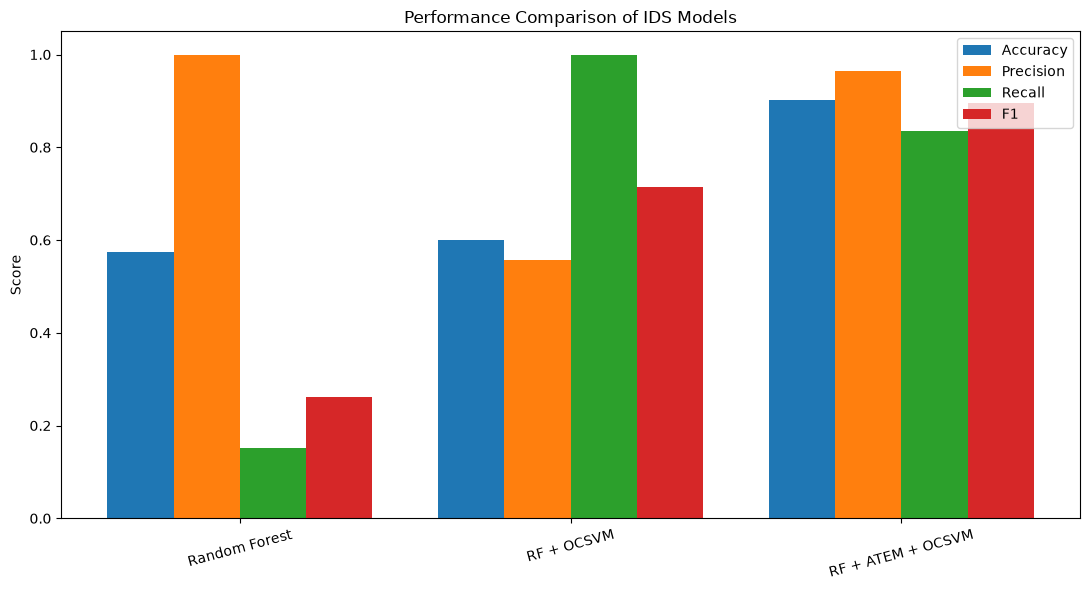

Graph saved successfully.


In [52]:
# ============================================================
# Cell 47: Final Model Performance Graph
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

models = comparison_df["Model"].values

accuracy = comparison_df["Accuracy"].values
precision = comparison_df["Precision"].values
recall = comparison_df["Recall"].values
f1 = comparison_df["F1"].values

x = np.arange(len(models))
width = 0.20

plt.figure(figsize=(11, 6))

plt.bar(x - 1.5*width, accuracy, width, label="Accuracy")
plt.bar(x - 0.5*width, precision, width, label="Precision")
plt.bar(x + 0.5*width, recall, width, label="Recall")
plt.bar(x + 1.5*width, f1, width, label="F1")

plt.xticks(x, models, rotation=15)
plt.ylabel("Score")
plt.title("Performance Comparison of IDS Models")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()

plt.savefig(
    r"E:\Hybrid_IDS_Project\dataset\results\final_model_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Graph saved successfully.")

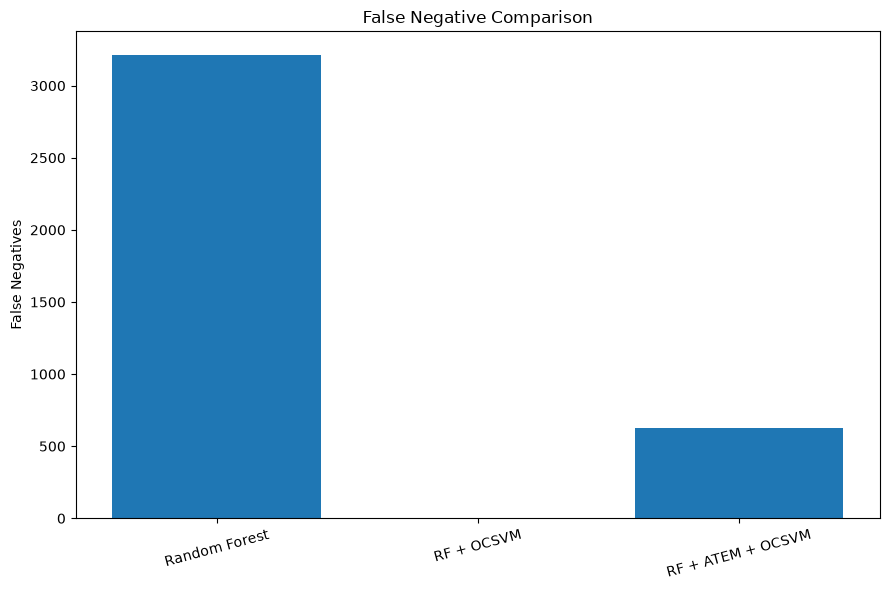

False-negative graph saved successfully.


In [53]:
# ============================================================
# Cell 48: False Negative Comparison
# ============================================================

plt.figure(figsize=(9, 6))

plt.bar(
    comparison_df["Model"],
    comparison_df["FN"]
)

plt.ylabel("False Negatives")
plt.title("False Negative Comparison")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    r"E:\Hybrid_IDS_Project\dataset\results\false_negative_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("False-negative graph saved successfully.")

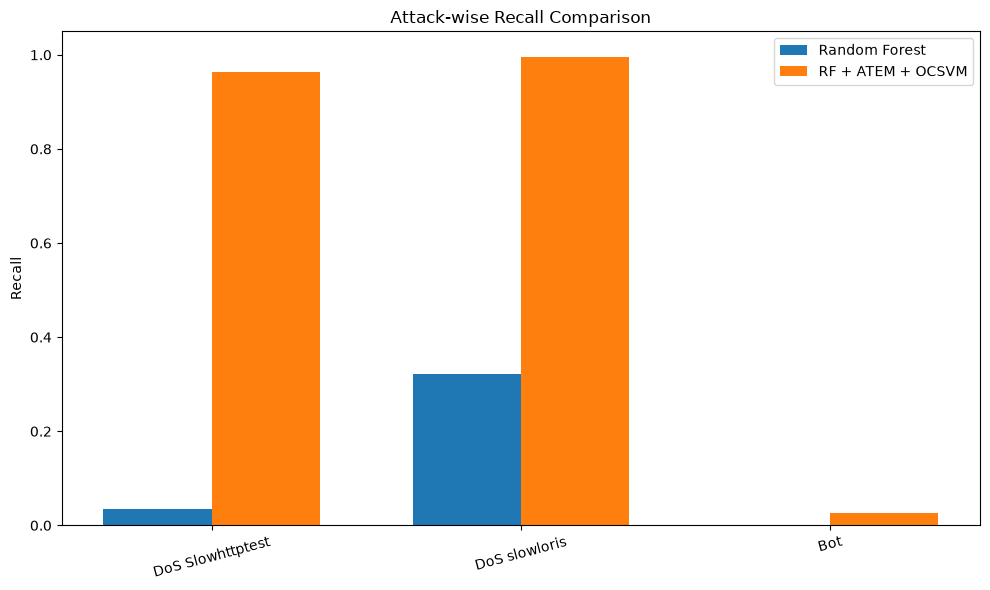

Attack-wise recall graph saved successfully.


In [54]:
# ============================================================
# Cell 49: Attack-wise Recall
# ============================================================

plot_df = attack_results_df[
    attack_results_df["Attack_Type"] != "BENIGN"
].copy()

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    plot_df["RF_Recall"],
    width,
    label="Random Forest"
)

plt.bar(
    x + width/2,
    plot_df["Hybrid_Recall"],
    width,
    label="RF + ATEM + OCSVM"
)

plt.xticks(
    x,
    plot_df["Attack_Type"],
    rotation=15
)

plt.ylabel("Recall")
plt.title("Attack-wise Recall Comparison")
plt.ylim(0, 1.05)
plt.legend()

plt.tight_layout()

plt.savefig(
    r"E:\Hybrid_IDS_Project\dataset\results\attackwise_recall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Attack-wise recall graph saved successfully.")

In [55]:
# ============================================================
# Cell 50: Verify Final Result Files
# ============================================================

import os

results_dir = r"E:\Hybrid_IDS_Project\dataset\results"

required_files = [
    "final_model_comparison.csv",
    "attackwise_results.csv",
    "final_model_performance.png",
    "false_negative_comparison.png",
    "attackwise_recall.png"
]

print("=" * 70)
print("FINAL RESULTS FILE VERIFICATION")
print("=" * 70)

for filename in required_files:

    path = os.path.join(results_dir, filename)

    if os.path.exists(path):
        size_kb = os.path.getsize(path) / 1024
        print(f"✓ {filename:<40} {size_kb:.1f} KB")
    else:
        print(f"✗ MISSING: {filename}")

FINAL RESULTS FILE VERIFICATION
✓ final_model_comparison.csv               0.4 KB
✓ attackwise_results.csv                   0.4 KB
✓ final_model_performance.png              96.4 KB
✓ false_negative_comparison.png            81.5 KB
✓ attackwise_recall.png                    88.4 KB


In [56]:
# ============================================================
# Cell 51: Verify Final Model Artifacts
# ============================================================

models_dir = r"E:\Hybrid_IDS_Project\dataset\models"

required_models = [
    "random_forest.pkl",
    "random_forest_unknown.pkl",
    "ocsvm.pkl",
    "ocsvm_unknown.pkl",
    "scaler.pkl",
    "hybrid.pkl",
    "mlp_unknown.pkl",
    "cnn_unknown.keras"
]

print("=" * 70)
print("FINAL MODEL ARTIFACT VERIFICATION")
print("=" * 70)

for filename in required_models:

    path = os.path.join(models_dir, filename)

    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"✓ {filename:<30} {size_mb:.2f} MB")
    else:
        print(f"✗ MISSING: {filename}")

FINAL MODEL ARTIFACT VERIFICATION
✓ random_forest.pkl              0.00 MB
✓ random_forest_unknown.pkl      28.35 MB
✓ ocsvm.pkl                      1.55 MB
✓ ocsvm_unknown.pkl              1.55 MB
✓ scaler.pkl                     0.00 MB
✓ hybrid.pkl                     0.00 MB
✓ mlp_unknown.pkl                0.63 MB
✓ cnn_unknown.keras              1.90 MB


In [57]:
# ============================================================
# Cell 52: Save Final Configuration
# ============================================================

import json

final_config = {
    "ATEM_threshold": 0.50,
    "OCSVM_threshold": float(BEST_OCSVM_THRESHOLD),

    "final_model": "Random Forest + ATEM + OCSVM",

    "test_samples": int(len(actual_test)),

    "accuracy": float(accuracy_final),
    "precision": float(precision_final),
    "recall": float(recall_final),
    "f1": float(f1_final),

    "true_negative": int(tn),
    "false_positive": int(fp),
    "false_negative": int(fn),
    "true_positive": int(tp),

    "RF_false_negatives": int(rf_result["FN"]),
    "Hybrid_false_negatives": int(hybrid_result["FN"]),

    "FN_reduction": int(
        rf_result["FN"] - hybrid_result["FN"]
    ),

    "FN_reduction_percent": float(
        (rf_result["FN"] - hybrid_result["FN"])
        / rf_result["FN"] * 100
    )
}

config_path = (
    r"E:\Hybrid_IDS_Project\dataset\results\final_configuration.json"
)

with open(config_path, "w") as f:
    json.dump(
        final_config,
        f,
        indent=4
    )

print("=" * 70)
print("FINAL CONFIGURATION SAVED")
print("=" * 70)
print(config_path)

print("\nConfiguration:")
print(json.dumps(final_config, indent=4))

FINAL CONFIGURATION SAVED
E:\Hybrid_IDS_Project\dataset\results\final_configuration.json

Configuration:
{
    "ATEM_threshold": 0.5,
    "OCSVM_threshold": 40.78100327375024,
    "final_model": "Random Forest + ATEM + OCSVM",
    "test_samples": 7537,
    "accuracy": 0.901817699349874,
    "precision": 0.9654856444715944,
    "recall": 0.8344772967265047,
    "f1": 0.8952138204474653,
    "true_negative": 3636,
    "false_positive": 113,
    "false_negative": 627,
    "true_positive": 3161,
    "RF_false_negatives": 3216,
    "Hybrid_false_negatives": 627,
    "FN_reduction": 2589,
    "FN_reduction_percent": 80.50373134328358
}
